# 08 · 토스 유입 기기의 첫날 행동

**한 줄 질문:** 앱인토스에서 게임을 연 기기들은 첫날 실제로 무엇을 했나?

이번에는 H4를 채택·기각하지 않는다. 토스 이용자의 규모와 행동 분포를 기술하는 G2 EDA다. 완료 기준은 날짜별 기기 수, 행동 0/1+ 기기 수, 활동 영역 수, 개별 행동 도달, 토스 연결 실패를 같은 분모로 제시하는 것. 작은 날짜별 표본의 우열·인과효과는 주장하지 않는다.

**중요한 정정:** 앞선 9/4 대 9/10 국내 신규 비교에는 토스와 웹이 섞였다. 이 노트북은 GA4 이벤트의 `platform='toss'`를 직접 사용한다. `traffic_source.source='toss'`는 토스 웹뷰 판정 기준이 아니다.

## 1. 모집단과 데이터 상태

- 첫 `platform='toss'` 이벤트가 기록된 날을 **첫 토스 관측일**로 정의한다. 기존 웹 이용자가 토스에서 다시 들어왔을 수도 있으므로 게임 자체의 첫 방문이라고 부르지 않는다.
- 분석 범위는 앱인토스 출시일인 2026-09-04부터 GA4의 마지막 완전 일별 export인 2026-09-12(KST)까지. 9/13 자체 세션 로그는 있지만 GA4 일별 export가 없어 행동 비교에 섞지 않는다.
- 베타 A/B 배정값 `beta_A`·`beta_B`가 기록된 기기는 제외한다. 이번 토스 이벤트와 자체 세션에는 해당 표식이 0건이지만, 이것만으로 미표식 테스터가 없다고 증명되지는 않는다.
- `user_pseudo_id`는 쿼리 내부 중복 제거에만 쓴다. 결과·CSV·W&B에는 기기별 식별자나 개별 행을 남기지 않는다.
- 기존에 감사한 의도적 행동 허용목록을 재사용한다. 자동 수집·`login`·경제 장부·`tutorial_skip`은 행동이 아니다. 행동 0 기기도 분모에 남긴다.
- 플랫폼 표식 없는 자동 GA4 이벤트나 게임 진입 전 이탈은 토스 이용자로 확정할 수 없어 이 표본에 들어오지 않는다.

In [1]:
from pathlib import Path
import os, sys
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parents[1]
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / 'ml'))
from calm_ml import bq, report as R

SQL_AUDIT = ROOT / 'ml/sql/g1_toss_identity_audit.sql'
SQL = ROOT / 'ml/sql/g2_toss_first_day_behavior.sql'
OUT = ROOT / 'ml/reports/g2_toss_behavior_2026-09-14'
OUT.mkdir(parents=True, exist_ok=True)
R.setup()
AREAS = {
    'nature_events': '자연·채집',
    'fishing_sea_events': '낚시·바다',
    'quest_social_events': '퀘스트·교류',
    'craft_home_events': '제작·집',
    'advanced_events': '고급 콘텐츠',
}
def wilson(k,n,z=1.96):
    p=k/n; den=1+z*z/n
    center=(p+z*z/(2*n))/den
    half=z*((p*(1-p)/n+z*z/(4*n*n))**.5)/den
    return center-half, center+half
print('분석 SQL:', SQL)


분석 SQL: /Users/uicheol_hwang/calm_forest/ml/sql/g2_toss_first_day_behavior.sql


## 2. 실행 SQL 원문과 표식 감사

아래 두 SQL 파일이 표본 정의의 원본이다. 첫 번째는 날짜별 토스·베타 표식의 기록 범위를 확인하고, 두 번째는 토스 플랫폼의 첫날 행동을 익명 기기 단위로 계산한다. 이 노트북은 익명 개별 행을 화면에 출력하지 않는다.

In [2]:
display(Markdown('```sql\n' + SQL_AUDIT.read_text(encoding='utf-8') + '\n```'))
display(Markdown('```sql\n' + SQL.read_text(encoding='utf-8') + '\n```'))
audit = bq.read_sql_file(str(SQL_AUDIT))
audit.to_csv(OUT / 'identity_audit.csv', index=False)
display(audit[['source','day','record_count','devices','toss_rows','toss_devices',
               'missing_event_platform_rows','beta_rows','toss_beta_rows']])


```sql
-- Toss is the in-app platform, not GA4 traffic_source.source='toss'.
-- Audit both independent platform markers and beta_A/beta_B markers before
-- defining a non-beta Toss cohort. No personal identifiers leave this query.
WITH ga4 AS (
  SELECT
    DATE(TIMESTAMP_MICROS(event_timestamp), 'Asia/Seoul') AS day,
    user_pseudo_id,
    event_name,
    (SELECT ep.value.string_value FROM UNNEST(event_params) ep
      WHERE ep.key = 'platform' LIMIT 1) AS event_platform,
    (SELECT up.value.string_value FROM UNNEST(user_properties) up
      WHERE up.key = 'platform' LIMIT 1) AS user_platform,
    (SELECT up.value.string_value FROM UNNEST(user_properties) up
      WHERE up.key = 'ab_variant' LIMIT 1) AS ab_variant,
    traffic_source.source AS acquisition_source
  FROM `calm-forest.analytics_547127440.events_*`
  WHERE _TABLE_SUFFIX NOT LIKE 'intraday_%'
    AND DATE(TIMESTAMP_MICROS(event_timestamp), 'Asia/Seoul')
        BETWEEN DATE '2026-09-04' AND DATE '2026-09-13'
),
raw_sessions AS (
  SELECT
    DATE(started_at, 'Asia/Seoul') AS day,
    client_id,
    platform,
    variant
  FROM `calm-forest.calm_forest_raw.session_logs`
  WHERE DATE(started_at, 'Asia/Seoul')
        BETWEEN DATE '2026-09-04' AND DATE '2026-09-13'
  QUALIFY ROW_NUMBER() OVER (
    PARTITION BY session_id ORDER BY updated_at DESC
  ) = 1
)
SELECT
  'GA4 events' AS source, day,
  COUNT(*) AS record_count,
  COUNT(DISTINCT user_pseudo_id) AS devices,
  COUNTIF(event_platform = 'toss') AS toss_rows,
  COUNT(DISTINCT IF(event_platform = 'toss', user_pseudo_id, NULL)) AS toss_devices,
  COUNTIF(event_platform IS NULL) AS missing_event_platform_rows,
  COUNTIF(user_platform = 'toss') AS toss_user_property_rows,
  COUNTIF(REGEXP_CONTAINS(COALESCE(ab_variant, ''), r'^beta_[AB]$')) AS beta_rows,
  COUNTIF(event_platform = 'toss' AND REGEXP_CONTAINS(
    COALESCE(ab_variant, ''), r'^beta_[AB]$')) AS toss_beta_rows,
  COUNTIF(LOWER(COALESCE(acquisition_source, '')) = 'toss') AS toss_source_rows
FROM ga4
GROUP BY day
UNION ALL
SELECT
  'deduped sessions' AS source, day,
  COUNT(*) AS record_count,
  COUNT(DISTINCT client_id) AS devices,
  COUNTIF(platform = 'toss') AS toss_rows,
  COUNT(DISTINCT IF(platform = 'toss', client_id, NULL)) AS toss_devices,
  COUNTIF(platform IS NULL) AS missing_event_platform_rows,
  CAST(NULL AS INT64) AS toss_user_property_rows,
  COUNTIF(REGEXP_CONTAINS(COALESCE(variant, ''), r'^beta_[AB]$')) AS beta_rows,
  COUNTIF(platform = 'toss' AND REGEXP_CONTAINS(
    COALESCE(variant, ''), r'^beta_[AB]$')) AS toss_beta_rows,
  CAST(NULL AS INT64) AS toss_source_rows
FROM raw_sessions
GROUP BY day
ORDER BY day, source;

```

```sql
-- G2: first observed Toss-platform day per GA4 device, through the last
-- available complete daily export (2026-09-12 KST). Toss means event param
-- platform='toss', NOT traffic_source.source='toss'.
-- Keep no-action devices in the denominator; drop marked beta_A/beta_B devices.
-- Automatic GA4 events, login, economy bookkeeping and tutorial_skip are not
-- deliberate play. No device/user identifier is returned or uploaded to W&B.
WITH base AS (
  SELECT
    DATE(TIMESTAMP_MICROS(event_timestamp), 'Asia/Seoul') AS day,
    event_timestamp,
    user_pseudo_id,
    event_name,
    device.category AS device,
    geo.country AS country,
    traffic_source.source AS acquisition_source,
    (SELECT ep.value.string_value FROM UNNEST(event_params) ep
      WHERE ep.key = 'platform' LIMIT 1) AS event_platform,
    (SELECT ep.value.string_value FROM UNNEST(event_params) ep
      WHERE ep.key = 'method' LIMIT 1) AS login_method,
    (SELECT ep.value.string_value FROM UNNEST(event_params) ep
      WHERE ep.key = 'result' LIMIT 1) AS connect_result,
    (SELECT up.value.string_value FROM UNNEST(user_properties) up
      WHERE up.key = 'ab_variant' LIMIT 1) AS ab_variant
  FROM `calm-forest.analytics_547127440.events_*`
  WHERE _TABLE_SUFFIX NOT LIKE 'intraday_%'
    AND user_pseudo_id IS NOT NULL
    AND DATE(TIMESTAMP_MICROS(event_timestamp), 'Asia/Seoul')
        BETWEEN DATE '2026-09-04' AND DATE '2026-09-12'
),
toss AS (
  SELECT * FROM base WHERE event_platform = 'toss'
),
first_toss AS (
  SELECT user_pseudo_id, MIN(day) AS first_toss_day
  FROM toss GROUP BY 1
),
first_day AS (
  SELECT t.*, f.first_toss_day
  FROM toss t JOIN first_toss f USING (user_pseudo_id)
  WHERE t.day = f.first_toss_day
),
features AS (
  SELECT
    user_pseudo_id,
    first_toss_day,
    ARRAY_AGG(STRUCT(COALESCE(device, '(unknown)') AS device,
                     COALESCE(country, '(unknown)') AS country,
                     COALESCE(acquisition_source, '(direct)') AS acquisition_source)
              ORDER BY event_timestamp LIMIT 1)[OFFSET(0)] AS profile,
    LOGICAL_OR(REGEXP_CONTAINS(COALESCE(ab_variant, ''), r'^beta_[AB]$')) AS beta_marked,
    COUNT(*) AS tracked_events,
    COUNTIF(event_name = 'toss_connect' AND connect_result = 'ok') AS connect_ok,
    COUNTIF(event_name = 'toss_connect' AND connect_result = 'fail') AS connect_fail,
    COUNTIF(event_name = 'login' AND login_method = 'toss') AS toss_login,
    COUNTIF(event_name = 'login_screen') AS login_screen,
    COUNTIF(event_name = 'tutorial_start') AS tutorial_start,
    COUNTIF(event_name = 'tutorial_complete') AS tutorial_complete,
    COUNTIF(event_name IN (
      'chop_tree','first_chop','plant_seed','water_crop','harvest_crop','forage_pick',
      'mine_ore','fishing_cast','fishing_catch','fishing_miss','sea_cast','sea_catch',
      'shop_sell','shop_buy','craft_item','place_decor','house_complete','house_expand',
      'npc_talk','quest_accept','quest_complete','gift_give','cooking_start','carve_start',
      'boat_start','mist_purify_start','firefly_swing','coop_build','coop_feed','coop_collect',
      'cafe_serve','photo_capture','dex_open','album_open','leaderboard_open'
    )) AS deliberate_events,
    COUNT(DISTINCT IF(event_name IN (
      'chop_tree','first_chop','plant_seed','water_crop','harvest_crop','forage_pick',
      'mine_ore','fishing_cast','fishing_catch','fishing_miss','sea_cast','sea_catch',
      'shop_sell','shop_buy','craft_item','place_decor','house_complete','house_expand',
      'npc_talk','quest_accept','quest_complete','gift_give','cooking_start','carve_start',
      'boat_start','mist_purify_start','firefly_swing','coop_build','coop_feed','coop_collect',
      'cafe_serve','photo_capture','dex_open','album_open','leaderboard_open'
    ), event_name, NULL)) AS deliberate_kinds,
    COUNTIF(event_name IN (
      'chop_tree','first_chop','plant_seed','water_crop','harvest_crop','forage_pick','mine_ore'
    )) AS nature_events,
    COUNTIF(event_name IN (
      'fishing_cast','fishing_catch','fishing_miss','sea_cast','sea_catch','boat_start'
    )) AS fishing_sea_events,
    COUNTIF(event_name IN (
      'npc_talk','quest_accept','quest_complete','gift_give'
    )) AS quest_social_events,
    COUNTIF(event_name IN (
      'shop_sell','shop_buy','craft_item','place_decor','house_complete','house_expand',
      'cooking_start','carve_start'
    )) AS craft_home_events,
    COUNTIF(event_name IN (
      'mist_purify_start','firefly_swing','coop_build','coop_feed','coop_collect',
      'cafe_serve','photo_capture','dex_open','album_open','leaderboard_open'
    )) AS advanced_events,
    ARRAY_AGG(DISTINCT IF(event_name IN (
      'chop_tree','first_chop','plant_seed','water_crop','harvest_crop','forage_pick',
      'mine_ore','fishing_cast','fishing_catch','fishing_miss','sea_cast','sea_catch',
      'shop_sell','shop_buy','craft_item','place_decor','house_complete','house_expand',
      'npc_talk','quest_accept','quest_complete','gift_give','cooking_start','carve_start',
      'boat_start','mist_purify_start','firefly_swing','coop_build','coop_feed','coop_collect',
      'cafe_serve','photo_capture','dex_open','album_open','leaderboard_open'
    ), event_name, NULL) IGNORE NULLS) AS reached_actions
  FROM first_day
  GROUP BY user_pseudo_id, first_toss_day
)
SELECT
  first_toss_day, profile.device AS device, profile.country AS country,
  profile.acquisition_source AS acquisition_source,
  beta_marked, tracked_events, connect_ok, connect_fail, toss_login,
  login_screen, tutorial_start, tutorial_complete,
  deliberate_events, deliberate_kinds, nature_events, fishing_sea_events,
  quest_social_events, craft_home_events, advanced_events, reached_actions
FROM features
WHERE NOT beta_marked
ORDER BY first_toss_day;

```

/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,source,day,record_count,devices,toss_rows,toss_devices,missing_event_platform_rows,beta_rows,toss_beta_rows
0,GA4 events,2026-09-04,2691,32,2250,21,226,0,0
1,deduped sessions,2026-09-04,42,19,32,14,2,0,0
2,GA4 events,2026-09-05,3004,18,2609,11,137,0,0
3,deduped sessions,2026-09-05,16,9,9,6,0,0,0
4,GA4 events,2026-09-06,2034,8,1918,4,57,0,0
5,deduped sessions,2026-09-06,8,6,6,4,0,0,0
6,GA4 events,2026-09-07,757,8,613,3,49,0,0
7,deduped sessions,2026-09-07,7,3,4,2,0,0,0
8,GA4 events,2026-09-08,865,11,163,4,104,0,0
9,deduped sessions,2026-09-08,25,10,8,4,0,0,0


## 3. 원시 기기 수와 날짜별 행동

한 기기가 첫 토스 관측일에 의도적 행동을 한 번이라도 했는지 센다. 총 이벤트 수만 보고 활동자가 많다고 판단하지 않는다. 날짜별 n이 작아 비율 순위는 매기지 않는다.

In [3]:
d = bq.read_sql_file(str(SQL))
area_cols = list(AREAS)
d['area_count'] = (d[area_cols] > 0).sum(axis=1)
d['acted'] = d.deliberate_events > 0
d['first_toss_day'] = pd.to_datetime(d.first_toss_day)
daily = d.groupby('first_toss_day', as_index=False).agg(
    devices=('acted','size'), acted_devices=('acted','sum'),
    deliberate_events=('deliberate_events','sum'),
    connect_fail_devices=('connect_fail',lambda s: int((s>0).sum())),
    toss_login_devices=('toss_login',lambda s: int((s>0).sum())),
)
daily['no_action_devices'] = daily.devices - daily.acted_devices
daily['action_rate'] = daily.acted_devices / daily.devices
daily.to_csv(OUT / 'daily_first_toss.csv', index=False)
display(daily)
print('전체 기기:',len(d),'행동 1회 이상:',int(d.acted.sum()),
      '행동 0:',int((~d.acted).sum()))


/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,first_toss_day,devices,acted_devices,deliberate_events,connect_fail_devices,toss_login_devices,no_action_devices,action_rate
0,2026-09-04,21,11,1305,2,19,10,0.52381
1,2026-09-05,9,5,1116,5,3,4,0.555556
2,2026-09-06,2,2,68,0,1,0,1.0
3,2026-09-08,1,1,7,1,0,0,1.0
4,2026-09-09,3,2,223,1,0,1,0.666667
5,2026-09-10,6,3,62,1,1,3,0.5
6,2026-09-11,4,2,57,3,0,2,0.5
7,2026-09-12,3,1,85,1,0,2,0.333333


전체 기기: 49 행동 1회 이상: 27 행동 0: 22


g2_toss_first_day_daily.png  969x630px


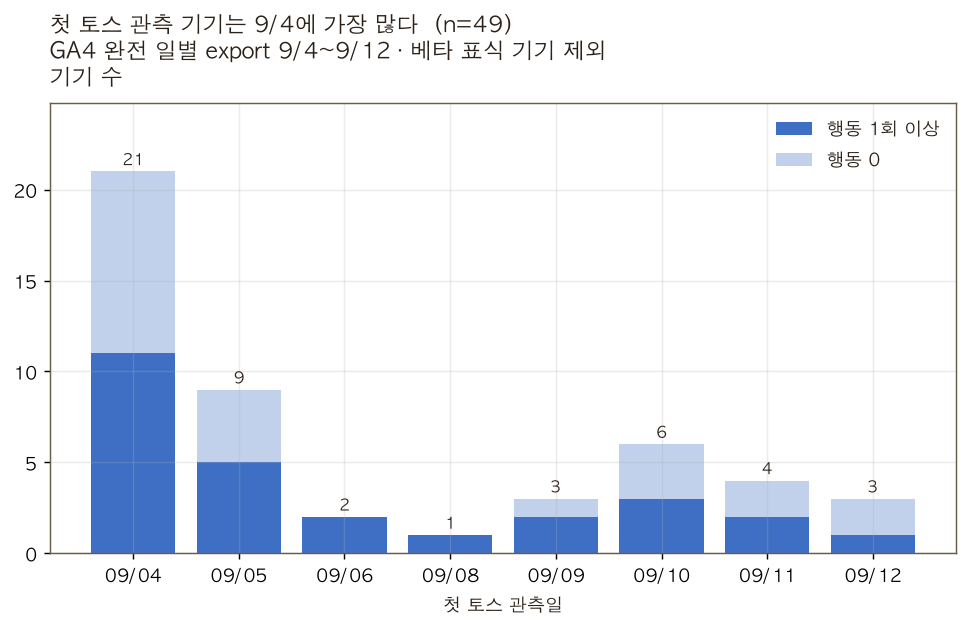

In [4]:
fig,ax=R.new('첫 토스 관측 기기는 9/4에 가장 많다',len(d),
             sub='GA4 완전 일별 export 9/4~9/12 · 베타 표식 기기 제외',ylab='기기 수',figsize=(9,4.5))
x=range(len(daily)); labels=daily.first_toss_day.dt.strftime('%m/%d')
ax.bar(x,daily.acted_devices,color=R.PALETTE[1],label='행동 1회 이상')
ax.bar(x,daily.no_action_devices,bottom=daily.acted_devices,
       color=R.tint(R.PALETTE[1],.68),label='행동 0')
for i,row in daily.iterrows():
    ax.text(i,row.devices+.35,str(row.devices),ha='center',fontsize=9)
ax.set_xticks(list(x),labels); ax.set_ylim(0,max(daily.devices)*1.18)
ax.legend(frameon=False); ax.set_xlabel('첫 토스 관측일')
chart_daily=R.save(fig,ax,'g2_toss_first_day_daily')
print(R.check(chart_daily)); display(R.show(chart_daily))


## 4. 행동 깊이 — 평균보다 분포

행동 0 기기와 극단적으로 많이 플레이한 기기가 공존한다. 행동 이벤트를 0, 1~5, 6~30, 31회 이상으로 묶어 기기 수를 본다. 구간은 보기 쉽게 나눈 기술적 범주이지 유저 등급이 아니다.

,행동 이벤트 수,기기 수
0,0회,22
1,1~5회,9
2,6~30회,8
3,31회 이상,10


중앙값 1.0 상위 5대 이벤트 2366 전체 이벤트 2923 상위 5대 비중 80.9
g2_toss_action_depth.png  868x571px


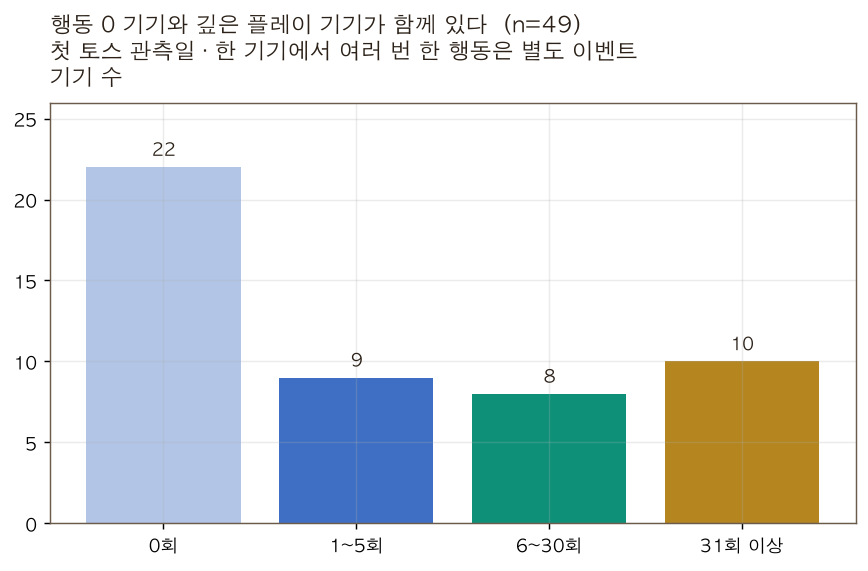

In [5]:
bins = pd.Series({
    '0회':int((d.deliberate_events==0).sum()),
    '1~5회':int(d.deliberate_events.between(1,5).sum()),
    '6~30회':int(d.deliberate_events.between(6,30).sum()),
    '31회 이상':int((d.deliberate_events>=31).sum()),
})
depth = bins.rename_axis('행동 이벤트 수').reset_index(name='기기 수')
depth.to_csv(OUT / 'action_depth.csv',index=False)
display(depth)
s=d.deliberate_events.sort_values(ascending=False)
print('중앙값',float(s.median()),'상위 5대 이벤트',int(s.head(5).sum()),
      '전체 이벤트',int(s.sum()),'상위 5대 비중',round(s.head(5).sum()/s.sum()*100,1))
fig,ax=R.new('행동 0 기기와 깊은 플레이 기기가 함께 있다',len(d),
             sub='첫 토스 관측일 · 한 기기에서 여러 번 한 행동은 별도 이벤트',ylab='기기 수')
bars=ax.bar(depth['행동 이벤트 수'],depth['기기 수'],color=[R.tint(R.PALETTE[1],.6),R.PALETTE[1],R.PALETTE[2],R.PALETTE[3]])
ax.bar_label(bars,padding=3);ax.set_ylim(0,max(depth['기기 수'])*1.18)
chart_depth=R.save(fig,ax,'g2_toss_action_depth')
print(R.check(chart_depth)); display(R.show(chart_depth))


## 5. 게임의 어느 영역에 갔나

5개 영역 각각에 한 번 이상 도달한 기기 수다. 한 기기가 여러 영역에 포함되므로 막대를 더해도 전체 기기 수가 되지 않는다. 영역 수 분포는 같은 기기가 얼마나 넓게 경험했는지 보여준다.

,영역,도달 기기,전체 대비 비율,95% 하한,95% 상한
0,자연·채집,20,0.408163,0.282150,0.547529
1,낚시·바다,9,0.183673,0.099762,0.313579
2,퀘스트·교류,20,0.408163,0.282150,0.547529
3,제작·집,13,0.265306,0.162111,0.402626
4,고급 콘텐츠,14,0.285714,0.178494,0.424091


,영역 수,기기 수
0,0,22
1,1,8
2,2,5
3,3,4
4,4,4
5,5,6


g2_toss_area_reach.png  960x571px


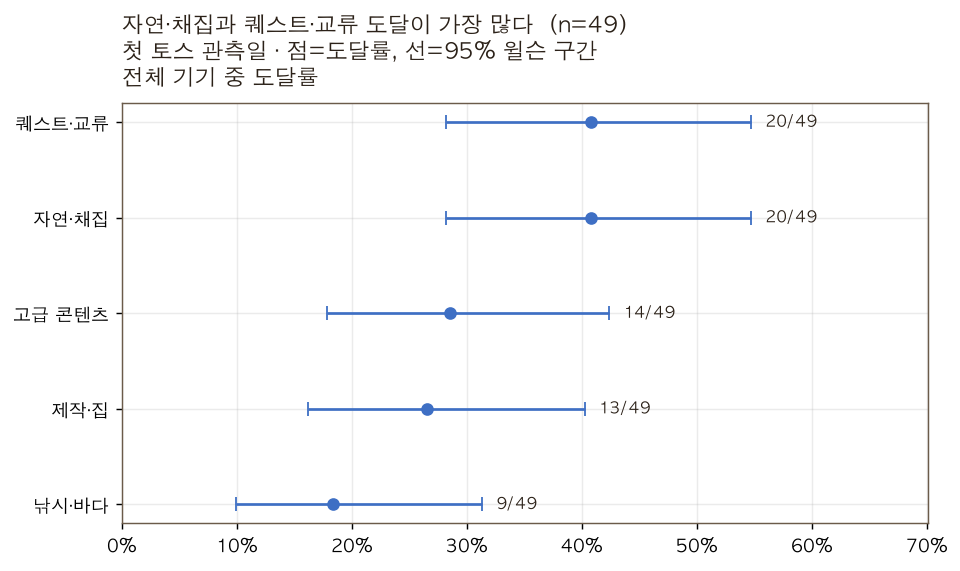

In [6]:
area = pd.DataFrame({'영역':list(AREAS.values()),
                     '도달 기기':[(d[c]>0).sum() for c in AREAS]})
area['전체 대비 비율']=area['도달 기기']/len(d)
area[['95% 하한','95% 상한']]=[wilson(k,len(d)) for k in area['도달 기기']]
area.to_csv(OUT/'area_reach.csv',index=False)
area_dist=d.area_count.value_counts().reindex(range(6),fill_value=0).rename_axis('영역 수').reset_index(name='기기 수')
area_dist.to_csv(OUT/'area_count_distribution.csv',index=False)
display(area);display(area_dist)
fig,ax=R.new('자연·채집과 퀘스트·교류 도달이 가장 많다',len(d),
             sub='첫 토스 관측일 · 점=도달률, 선=95% 윌슨 구간',ylab='전체 기기 중 도달률')
a=area.sort_values('도달 기기')
y=range(len(a))
ax.errorbar(a['전체 대비 비율'],list(y),
            xerr=[a['전체 대비 비율']-a['95% 하한'],a['95% 상한']-a['전체 대비 비율']],
            fmt='o',color=R.PALETTE[1],capsize=4)
ax.set_yticks(list(y),a['영역']);ax.set_xlim(0,max(a['95% 상한'])*1.28)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1))
for i,(_,row) in enumerate(a.iterrows()):
    ax.text(row['95% 상한']+.012,i,f"{int(row['도달 기기'])}/{len(d)}",va='center',fontsize=9)
chart_area=R.save(fig,ax,'g2_toss_area_reach',zero_base=False)
print(R.check(chart_area));display(R.show(chart_area))


g2_toss_area_count_distribution.png  868x571px


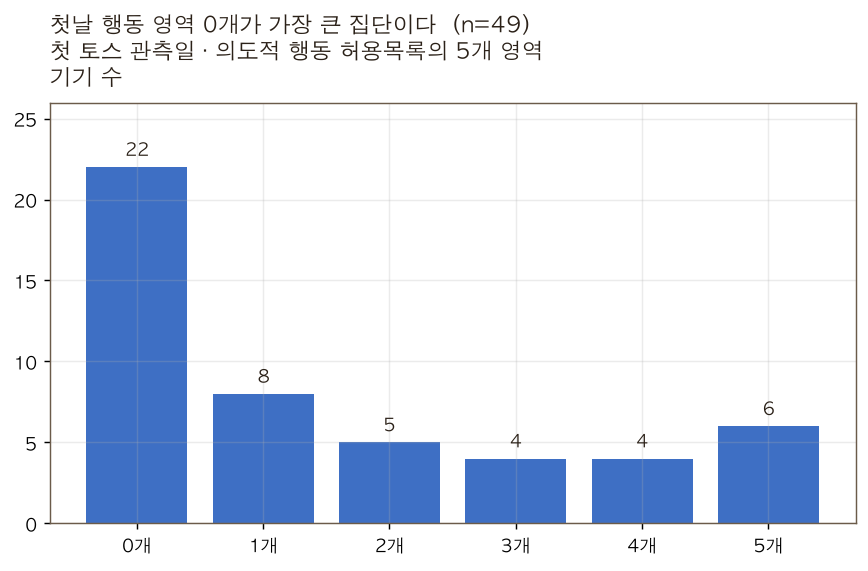

In [7]:
fig,ax=R.new('첫날 행동 영역 0개가 가장 큰 집단이다',len(d),
             sub='첫 토스 관측일 · 의도적 행동 허용목록의 5개 영역',ylab='기기 수')
bars=ax.bar(area_dist['영역 수'].astype(str)+'개',area_dist['기기 수'],color=R.PALETTE[1])
ax.bar_label(bars,padding=3);ax.set_ylim(0,max(area_dist['기기 수'])*1.18)
chart_area_dist=R.save(fig,ax,'g2_toss_area_count_distribution')
print(R.check(chart_area_dist));display(R.show(chart_area_dist))


## 6. 실제로 한 행동

같은 행동을 100번 한 기기도 이 표에서는 1대로 센다. 행동 종류별 도달 기기 수 상위 12개를 보여준다. 순서는 행동의 **시간 순서**가 아니다.

,행동,도달 기기,도달률,95% 하한,95% 상한
0,npc_talk,20,0.408163,0.282150,0.547529
1,quest_accept,17,0.346939,0.229242,0.486891
2,first_chop,17,0.346939,0.229242,0.486891
3,chop_tree,17,0.346939,0.229242,0.486891
4,plant_seed,16,0.326531,0.212073,0.466211
5,harvest_crop,11,0.224490,0.130248,0.358791
6,shop_sell,10,0.204082,0.114817,0.336373
7,house_complete,9,0.183673,0.099762,0.313579
8,quest_complete,9,0.183673,0.099762,0.313579
9,water_crop,8,0.163265,0.085126,0.290366


g2_toss_action_reach.png  977x751px


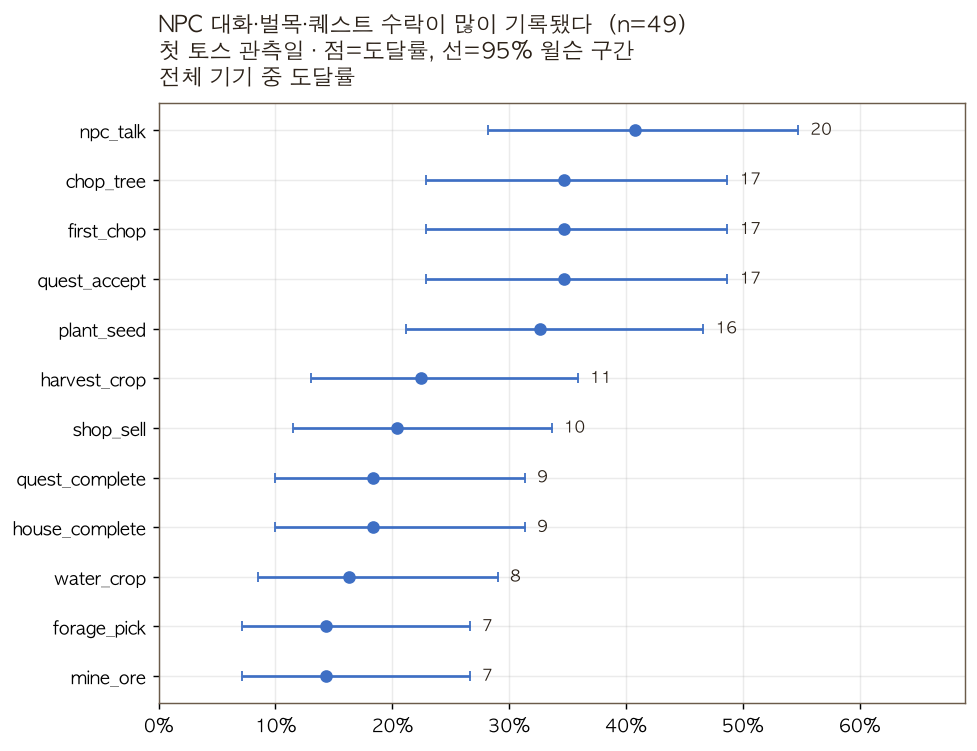

In [8]:
action_reach=d.reached_actions.explode().dropna().value_counts().rename_axis('행동').reset_index(name='도달 기기')
action_reach['도달률']=action_reach['도달 기기']/len(d)
action_reach[['95% 하한','95% 상한']]=[wilson(k,len(d)) for k in action_reach['도달 기기']]
action_reach.to_csv(OUT/'action_reach.csv',index=False)
display(action_reach.head(12))
top=action_reach.head(12).sort_values('도달 기기')
fig,ax=R.new('NPC 대화·벌목·퀘스트 수락이 많이 기록됐다',len(d),
             sub='첫 토스 관측일 · 점=도달률, 선=95% 윌슨 구간',ylab='전체 기기 중 도달률',figsize=(8,6))
y=range(len(top))
ax.errorbar(top['도달률'],list(y),
            xerr=[top['도달률']-top['95% 하한'],top['95% 상한']-top['도달률']],
            fmt='o',color=R.PALETTE[1],capsize=3)
ax.set_yticks(list(y),top['행동']);ax.set_xlim(0,max(top['95% 상한'])*1.26)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1))
for i,(_,row) in enumerate(top.iterrows()):
    ax.text(row['95% 상한']+.01,i,str(int(row['도달 기기'])),va='center',fontsize=9)
chart_actions=R.save(fig,ax,'g2_toss_action_reach',zero_base=False)
print(R.check(chart_actions));display(R.show(chart_actions))


## 7. 토스 연결 이벤트

연결 실패를 경험한 기기, 토스 로그인이 기록된 기기, 로그인 화면을 본 기기는 **서로 겹칠 수 있다**. 따라서 순차 전환 퍼널로 그리지 않는다. 실패 뒤 재시도나 게스트 폴백이 있었는지는 개별 순서 검증 없이 단정하지 않는다.

,사건,기기 수
0,연결 실패 1회 이상,14
1,토스 로그인 기록,24
2,로그인 화면 기록,12


g2_toss_connection_events.png  868x571px


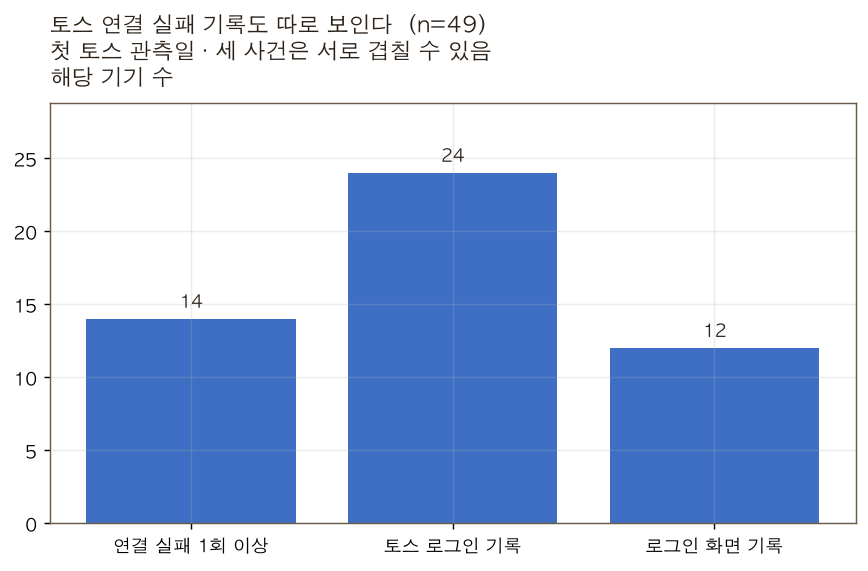

In [9]:
connect=pd.DataFrame({
    '사건':['연결 실패 1회 이상','토스 로그인 기록','로그인 화면 기록'],
    '기기 수':[int((d.connect_fail>0).sum()),int((d.toss_login>0).sum()),
              int((d.login_screen>0).sum())],
})
connect.to_csv(OUT/'connection_events.csv',index=False)
display(connect)
fig,ax=R.new('토스 연결 실패 기록도 따로 보인다',len(d),
             sub='첫 토스 관측일 · 세 사건은 서로 겹칠 수 있음',ylab='해당 기기 수')
bars=ax.bar(connect['사건'],connect['기기 수'],color=R.PALETTE[1])
ax.bar_label(bars,padding=3);ax.set_ylim(0,max(connect['기기 수'])*1.2)
chart_connect=R.save(fig,ax,'g2_toss_connection_events')
print(R.check(chart_connect));display(R.show(chart_connect))


## 8. 그래서 크기가 얼마나 되나

아래 결론은 이 실행에서 나온 집계표로만 만든다. 수치가 바뀌면 문장도 같이 바뀐다.

In [10]:
n=len(d);acted=int(d.acted.sum());zero=n-acted
top5=int(s.head(5).sum());total=int(s.sum())
display(Markdown(f'''토스 플랫폼으로 처음 관측된 기기 **{n}대** 중 **{acted}대({acted/n:.1%})**가 첫날 의도적 행동을 1회 이상 했고, **{zero}대({zero/n:.1%})**는 해당 행동 기록이 없다. 기기당 행동 이벤트 중앙값은 **{s.median():.0f}회**다. 반면 상위 5대가 전체 {total:,}건 중 **{top5:,}건({top5/total:.1%})**을 남겼다. 평균보다 행동 여부와 꼬리 분포를 보는 편이 낫다.'''))


토스 플랫폼으로 처음 관측된 기기 **49대** 중 **27대(55.1%)**가 첫날 의도적 행동을 1회 이상 했고, **22대(44.9%)**는 해당 행동 기록이 없다. 기기당 행동 이벤트 중앙값은 **1회**다. 반면 상위 5대가 전체 2,923건 중 **2,366건(80.9%)**을 남겼다. 평균보다 행동 여부와 꼬리 분포를 보는 편이 낫다.

## 9. 이 숫자로 말할 수 없는 것

- **토스 전체 노출자 수가 아니다.** 플랫폼 표식이 붙기 전 앱을 닫은 기기는 빠질 수 있다. GA4 자동 이벤트 중 `platform`이 없는 행도 토스/웹으로 안전하게 나눌 수 없다.
- 이번 표본은 `beta_A/B` 표식이 있는 기기를 제외했지만, 표식이 찍히지 않은 내부 사용자나 개발 테스트까지 완벽히 걸러낸 것은 아니다. 깊은 꼬리는 이 가능성에 특히 민감하다.
- 9/13 GA4 일별 export가 아직 없다. 9/13 자체 세션 로그를 9/12까지의 행동 이벤트와 같은 기간처럼 합치지 않았다.
- `user_pseudo_id`는 사람이 아니라 브라우저/기기에 가깝다. 첫 토스 관측일은 게임 최초 방문일과 다르다.
- `traffic_source.source`는 전부 `(direct)`였지만, 앱인토스 유입이 없었다는 뜻이 아니다. 플랫폼 표식으로 분리해야 한다.
- 이벤트 허용목록에 없는 실제 행동은 0 또는 낮은 영역 수로 잡힌다. 연결 실패와 로그인 기록은 겹칠 수 있고, 이벤트 timestamp 동률 때문에 이 표의 순서·퍼널은 검증하지 않았다.
- 전체 49대, 날짜별 1~21대여서 날짜별 도달률 차이·기기별 우열·인과효과를 판단하지 않는다.

## 10. 다음에 확인할 것

첫 토스 관측일의 연결 실패가 실제 플레이 진입을 가로막았는지는 **연결 시도 → 성공/폴백 → 첫 행동**의 순서를 안정적으로 기록한 뒤 별도 게이트에서 확인한다. 이번 결과로 연결 실패가 이탈을 일으켰다고 주장하지 않는다. 9/13 이후 GA4 export가 채워지면 같은 SQL을 기간만 늘려 다시 돌린다. 여기서 멈춘다.

## 11. 가정과 W&B 기록

| 가정 | 근거 | 신뢰 | 틀렸을 때 영향 | 검증 |
|---|---|---|---|---|
| 이벤트 `platform=toss`가 토스 웹뷰를 뜻함 | `js/analytics.js`·`js/platform.js` | 높음 | 표본 오분류 | 자체 세션의 platform 일별 수와 대조 |
| `beta_A/B` 미표식 토스 기기를 일반 유입의 근사치로 사용 | GA4·자체 세션 토스 행에서 베타 표식 0 | 중간 | 내부 사용자 혼입 | 배정 명단과 기기 매핑 커버리지 점검 |
| 의도적 행동 목록이 플레이를 대표 | 앞선 행동 감사에서 재사용 | 중간 | 행동률 과소·왜곡 | 신규 이벤트 추가분 점검 |
| 9/12까지 완전 일별 export로 범위를 고정 | 날짜별 표식 감사 | 높음 | 최신 일자 제외 | GA4 일별 export 생성 뒤 재실행 |

W&B 업로드는 안전 검토에서 보류됐다. 이 실행은 로컬 집계표와 PNG까지만 만든다. 외부 실험 기록은 업로드 항목·목적지에 대한 별도 승인 뒤 수행한다. 익명 기기별 행과 식별자는 어떤 경우에도 W&B에 보내지 않는다.